# The Thematic ETF Curse — why the fund's birthday is the sell signal 🪤
### Solar, cannabis, metaverse, blockchain: what a dollar invested at *every* thematic ETF launch actually earned

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Buy the dip?: Busted](https://img.shields.io/badge/Buy_the_--50%25_dip%3F-Busted-8b949e?style=flat-square)

Here's a pattern you've lived through even if you never traded it. A theme gets hot — solar in 2008, robotics in 2016, cannabis in 2018, the metaverse and blockchain in 2021. It's on magazine covers. Your feed is full of it. And *right then* — never earlier — a fund company launches an ETF so you can "get exposure" with one click.

A 2023 academic paper (Ben-David, Franzoni, Kim & Moussawi, *Competition for Attention in the ETF Space*) made a brutal claim about those products: **they launch at peak hype and then lose about 5% a year, risk-adjusted, for years**. Not because ETFs are bad — broad index ETFs are wonderful — but because the *launch date itself* marks the top of the theme's attention. The fund is born holding the theme at its most expensive.

We test it on **48 real thematic ETF launches (2005–2021)** — the full ARK complex, TAN, HACK, KWEB, MSOS, BUZZ, METV, BKCH and friends — against **13 boring broad-index ETF launches** as the control.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the placebo regressions and the borrow math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front, and it makes the result STRONGER.** The thematic ETFs that died — and many did — have vanished from Yahoo's data. Our panel only holds the *survivors*, the best of the litter. Every negative number below is therefore an **understatement** of the curse.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from thematic_etf_curse import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, RF = data.load_prices(), data.load_rf()
    UNIV = data.build_universe(PX, RF, as_of="2026-06-30")
    TH, BR = UNIV["thematic"], UNIV["broad"]
else:
    PX = RF = UNIV = None
    TH = BR = []
print("real cache present:", HAVE_REAL, "| thematic:", len(TH), "| broad placebo:", len(BR))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fingerprint': 'd3175d6dbc14', 'n_thematic': 48, 'n_broad': 13, 'launches': '2005-2021', 'hype_vintage': 20, 'young36': (-16.3, -3.27, 1.64, 192, 8.7), 'young36_span': ('2008-07-31', '2024-06-30'), 'young12': (-15.0, -2.04, 1.64, 109, 4.5), 'seasoned': (-10.33, -1.82, 1.36, 182, 23.6), 'spread': (-0.26, -0.05, 158), 'placebo': (0.31, 1.17, 0.99, 72), 'curve': {12: -4.9, 24: -12.4, 36: -22.5, 48: -35.6}, 'curve_n': 48, 'perfund_median': -2.18, 'perfund_pct_neg': 65, 'perfund_n': 48, 'rob_lags12': (-16.3, -2.93), 'rob_min1': (-11.29, -2.32, 232), 'rob_exark': (-16.49, -3.34, 42), 'rob_pre18': (-18.94, -3.99, 28, 135), 'rob_post18': (-9.56, -0.97, 20, 74), 'short_gross': (16.3, 3.58), 'short': [(300, 13.21, 2.9), (600, 10.21, 2.24), (1000, 6.21, 1.37)], 'dip_events': 34, 'dip_alpha': -19.39, 'dip_t': -2.8, 'dip_beta': 1.63, 'dip_n': 83, 'dip_fwd12': (-15.1, 76, 34), 'dip_fwd36': (-36.6, 75, 32), 'syn': [(0.0, -0.76, -0.37), (-8.0, -8.76, -4.26)], 'syn_n': 181}


real cache present: True | thematic: 48 | broad placebo: 13


## The answer first

| Question | Answer |
|---|---|
| Do thematic ETFs bleed after launch? | **Yes, heavily.** A portfolio that always held the freshly launched thematics lost about **16% a year** vs what its market risk should have paid (the quants' *t* = −3.3 — far past the desk's bar). |
| Is it just "new ETFs" in general? | **No.** The same experiment on broad index-fund launches (VTI, VOO, Schwab...) shows **zero** bleed. It's the *hype*, not the launch. |
| Does the bleed stop? | Not really — older thematics still bled ~10%/yr on this sample. The launch is when the bleed *starts*, not the only bad year. |
| "It's down 50%, it's cheap now"? | **Busted.** Buying the halved thematics lost another **37 percentage points** to the S&P over the next 3 years, three times out of four. |
| Can you get rich shorting them? | On paper yes; in practice borrow fees and thin supply eat most of it. The **free** trade is simply *not buying the launch*. |

## 1 · The curse curve — what happens after the first candle

Take all 48 funds, line them up on their **launch month** (month 1 = first full month of trading), strip out what the market itself did (each fund's beta × the S&P), and average. This is the pure "being a young thematic ETF" effect, month by month after birth.

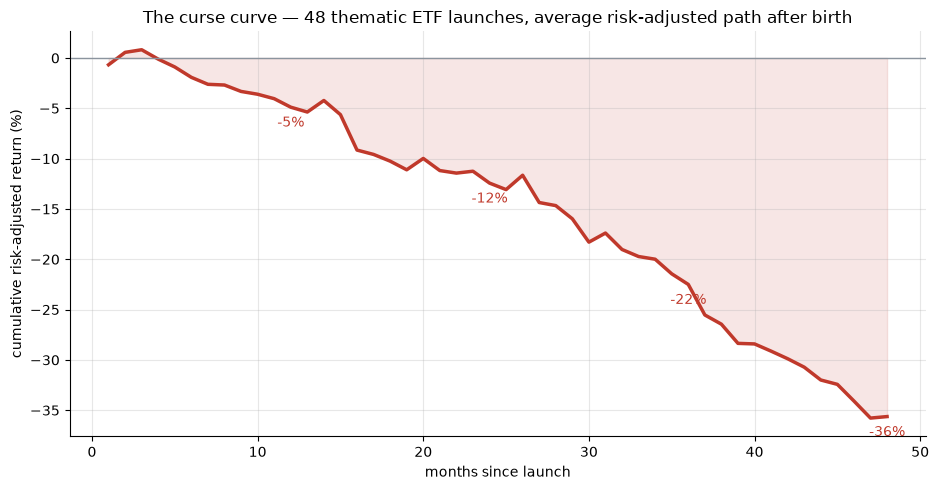

cumulative risk-adjusted return by event month (canonical): {12: -4.9, 24: -12.4, 36: -22.5, 48: -35.6}


In [2]:
if HAVE_REAL:
    ec = st.event_curve(UNIV, TH, k_max=48)
    fig, ax = plt.subplots()
    ax.plot(ec.index, ec['cum_ab_pct'], color=RED, lw=2.5)
    ax.fill_between(ec.index, ec['cum_ab_pct'], 0, color=RED, alpha=.12)
    ax.axhline(0, color=GREY, lw=1)
    for k in (12, 24, 36, 48):
        ax.annotate(f"{ec.loc[k,'cum_ab_pct']:+.0f}%", (k, ec.loc[k,'cum_ab_pct']),
                    textcoords='offset points', xytext=(0, -14), ha='center', color=RED)
    ax.set_xlabel('months since launch'); ax.set_ylabel('cumulative risk-adjusted return (%)')
    ax.set_title(f'The curse curve — {len(TH)} thematic ETF launches, average risk-adjusted path after birth')
    plt.tight_layout(); plt.show()
else:
    print('cache missing — canonical numbers:', R['curve'])
print('cumulative risk-adjusted return by event month (canonical):', R['curve'])

Read it left to right: **−5% by the first birthday, −12% by the second, −22% by the third, −36% by month 48**. No dramatic crash on day one — just a steady, grinding bleed as the hype premium leaks out. And remember: the funds that bled *worst* closed and aren't even in this average.

> 🔬 **For the quants.** The curve uses each fund's full-sample beta (documented look-ahead, fine for a descriptive picture). The *headline* test has no look-ahead at all: a calendar-time portfolio and a Newey-West *t* — notebook 02.

## 2 · The honest experiment — hold ALL the young thematics, always

Imagine a fund-of-funds with one dumb rule: **every month, own every thematic ETF that is less than 3 years old**, equal-weighted. That's the strategy "buy the launches". Its risk-adjusted return is the whole claim in one number. We race it against the same rule applied to boring broad-index launches.

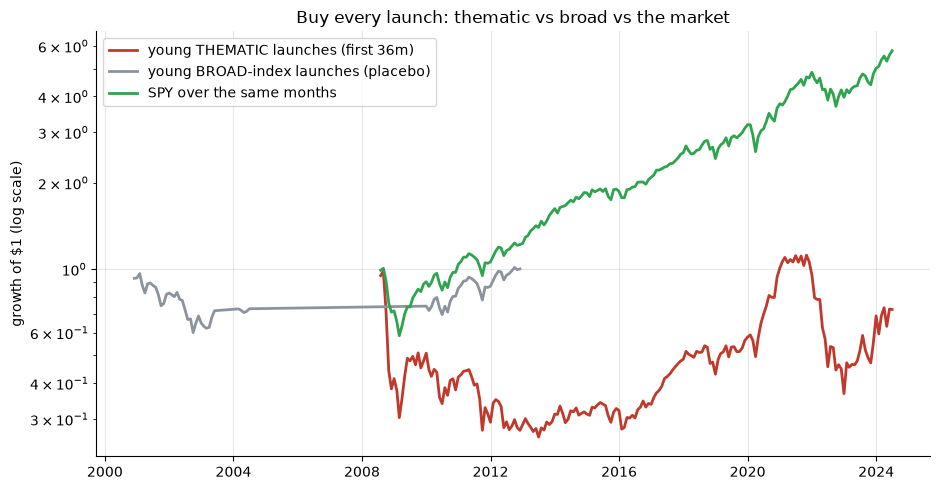

canonical: young thematics alpha -16.30%/yr (t=-3.27) | broad placebo +0.31%/yr (t=+1.17)


In [3]:
if HAVE_REAL:
    py, _ = st.calendar_time_portfolio(UNIV, TH, 1, 36)
    pb, _ = st.calendar_time_portfolio(UNIV, BR, 1, 36)
    spy = UNIV['mkt']
    fig, ax = plt.subplots()
    for s, lbl, c in ((py, 'young THEMATIC launches (first 36m)', RED),
                      (pb, 'young BROAD-index launches (placebo)', GREY),
                      (spy.reindex(py.index), 'SPY over the same months', GREEN)):
        s = s.dropna()
        ax.plot(s.index, (1 + s).cumprod(), color=c, lw=2, label=lbl)
    ax.set_yscale('log'); ax.legend(); ax.set_ylabel('growth of $1 (log scale)')
    ax.set_title('Buy every launch: thematic vs broad vs the market')
    plt.tight_layout(); plt.show()
else:
    print('cache missing')
print(f"canonical: young thematics alpha {R['young36'][0]:+.2f}%/yr (t={R['young36'][1]:+.2f}) | "
      f"broad placebo {R['placebo'][0]:+.2f}%/yr (t={R['placebo'][1]:+.2f})")

The young-thematics book lost **−16.3% a year of alpha** — that is, versus what its own (very high) market risk should have earned. The broad-launch placebo: **+0.3%/yr, statistically zero**. Same construction, same math, same era. The only difference is *what* was launched: hype versus plumbing.

The comparison to SPY on the chart looks even crueler than −16%/yr because these funds carry beta ≈ 1.6 — they were *supposed* to beat SPY in the good times just by being risky. They didn't.

> 💡 **Why does the industry keep doing it?** Because launches follow *attention*. A thematic ETF gathers assets easiest exactly when the theme is on magazine covers — which is also when it's most expensive. The fund company harvests fees either way; you hold the bag. That's the paper's whole mechanism, and our tape agrees.

## 3 · "But it's down 50% now — surely it's cheap?"

The most seductive counter-move: wait for the crash, buy the wreckage. 34 of our 48 funds did lose half their value from their post-launch peak. Suppose you bought each one the month after it first closed −50% down, and held for 3 years. Versus just buying SPY the same day:

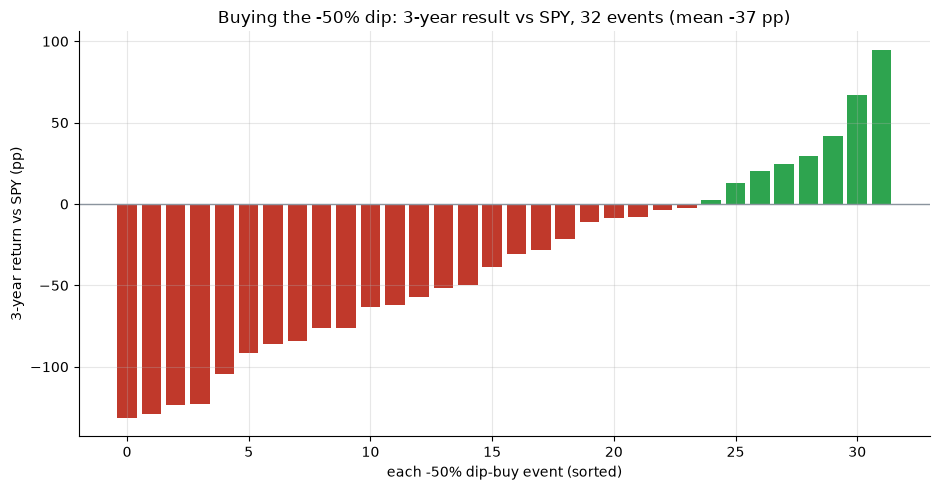

canonical: mean 3y vs SPY -36.6 pp, 75% of 32 events negative | dip-book alpha -19.39%/yr (t=-2.80)


In [4]:
if HAVE_REAL:
    dp = st.dip_portfolio(UNIV, TH, dd=0.50, hold=36)
    f36 = np.array(dp['fwd36']) * 100
    fig, ax = plt.subplots()
    f = np.sort(f36)
    ax.bar(range(len(f)), f, color=[RED if v < 0 else GREEN for v in f])
    ax.axhline(0, color=GREY, lw=1)
    ax.set_xlabel('each -50% dip-buy event (sorted)'); ax.set_ylabel('3-year return vs SPY (pp)')
    ax.set_title(f"Buying the -50% dip: 3-year result vs SPY, {len(f)} events (mean {f.mean():+.0f} pp)")
    plt.tight_layout(); plt.show()
else:
    print('cache missing')
print(f"canonical: mean 3y vs SPY {R['dip_fwd36'][0]:+.1f} pp, {R['dip_fwd36'][1]}% of "
      f"{R['dip_fwd36'][2]} events negative | dip-book alpha {R['dip_alpha']:+.2f}%/yr (t={R['dip_t']:+.2f})")

**Busted.** The average dip-buy lost another **37 points** to the S&P over three years; **three out of four** dips lost. "Down 50%" doesn't mean cheap — it means the hype premium is *half* deflated. In these products, the knife keeps falling.


## The takeaway

1. **The curse is real.** Across 48 launches and 20 years, freshly launched thematic ETFs bled ~16%/yr of risk-adjusted return; the boring-launch placebo bled nothing. And the dead funds Yahoo forgot would only make it worse.
2. **The launch date is the tell.** The product exists *because* the theme just peaked in attention. You're not early — the launch proves you're late.
3. **The dip is not your friend** here. −50% was mid-bleed, not a bottom, three times out of four.
4. **The tradable lesson is free.** Shorting the launches works on paper but borrow fees and thin supply eat most of it (quants' notebook). Simply *declining to buy* the shiny new theme fund — and buying the boring broad fund instead — captures the entire effect at zero cost.

*Research & education, not investment advice. Numbers: [docs/results.md](../docs/results.md), as-of 2026-06-30.*